# Smart Energy Consumption Analysis and Prediction using Machine Learning with Device-Level Insights 

## Module 1: Data Collection and Understanding  

#### The scope of this project is to collect, organize and analyze smart home energy consumption data at the device level in order to understand energy usage patterns and improve efficiency. The system processes timestamped appliance level power readings to extract insights, identify high consumption devices and enable forecasting of future energy demand using machine learning models. Ultimately, the project aims to support smarter energy usage decisions and reduce overall electricity costs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('./HomeC.csv',low_memory=False)
df.head(10)

,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
0,1451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1,1451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2,1451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
3,1451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
4,1451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
5,1451624405,1.391867,0.003433,1.391867,0.000283,0.503250,0.063667,0.447033,0.122300,0.006717,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
6,1451624406,1.366217,0.003450,1.366217,0.000283,0.499400,0.063717,0.443267,0.122050,0.006733,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
7,1451624407,1.431900,0.003417,1.431900,0.000250,0.477867,0.178633,0.444283,0.121800,0.006783,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
8,1451624408,1.627300,0.003417,1.627300,0.000183,0.447650,0.365700,0.441467,0.121617,0.006950,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
9,1451624409,1.735383,0.003417,1.735383,0.000017,0.171550,0.682500,0.438733,0.121633,0.007233,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


### Data types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503911 entries, 0 to 503910
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   time                 503911 non-null  object 
 1   use [kW]             503910 non-null  float64
 2   gen [kW]             503910 non-null  float64
 3   House overall [kW]   503910 non-null  float64
 4   Dishwasher [kW]      503910 non-null  float64
 5   Furnace 1 [kW]       503910 non-null  float64
 6   Furnace 2 [kW]       503910 non-null  float64
 7   Home office [kW]     503910 non-null  float64
 8   Fridge [kW]          503910 non-null  float64
 9   Wine cellar [kW]     503910 non-null  float64
 10  Garage door [kW]     503910 non-null  float64
 11  Kitchen 12 [kW]      503910 non-null  float64
 12  Kitchen 14 [kW]      503910 non-null  float64
 13  Kitchen 38 [kW]      503910 non-null  float64
 14  Barn [kW]            503910 non-null  float64
 15  Well [kW]        

### Missing values

In [3]:
df.isnull().sum()

time                   0
use [kW]               1
gen [kW]               1
House overall [kW]     1
Dishwasher [kW]        1
Furnace 1 [kW]         1
Furnace 2 [kW]         1
Home office [kW]       1
Fridge [kW]            1
Wine cellar [kW]       1
Garage door [kW]       1
Kitchen 12 [kW]        1
Kitchen 14 [kW]        1
Kitchen 38 [kW]        1
Barn [kW]              1
Well [kW]              1
Microwave [kW]         1
Living room [kW]       1
Solar [kW]             1
temperature            1
icon                   1
humidity               1
visibility             1
summary                1
apparentTemperature    1
pressure               1
windSpeed              1
cloudCover             1
windBearing            1
precipIntensity        1
dewPoint               1
precipProbability      1
dtype: int64

### Converting time from unix second format to normal date and time format

In [4]:
df['time']=pd.to_numeric(df['time'], errors='coerce')
df=df.dropna(subset=['time'])
df['time']=pd.to_datetime(df['time'], unit='s')
df=df.set_index('time').sort_index()
print(df.index[:5])

DatetimeIndex(['2016-01-01 05:00:00', '2016-01-01 05:00:01',
               '2016-01-01 05:00:02', '2016-01-01 05:00:03',
               '2016-01-01 05:00:04'],
              dtype='datetime64[ns]', name='time', freq=None)


### Checking duplicates

In [5]:
df.duplicated()

time
2016-01-01 05:00:00    False
2016-01-01 05:00:01    False
2016-01-01 05:00:02    False
2016-01-01 05:00:03    False
2016-01-01 05:00:04    False
                       ...  
2016-01-07 00:58:25    False
2016-01-07 00:58:26    False
2016-01-07 00:58:27    False
2016-01-07 00:58:28    False
2016-01-07 00:58:29    False
Length: 503910, dtype: bool

In [6]:
df.duplicated().sum()

np.int64(171)

In [7]:
df=df.drop_duplicates(keep='first')

In [8]:
df.duplicated().sum()

np.int64(0)

### Exploratory statistics

In [10]:
df.describe()

,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],Garage door [kW],...,temperature,humidity,visibility,apparentTemperature,pressure,windSpeed,windBearing,precipIntensity,dewPoint,precipProbability
count,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,...,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000,503739.000000
mean,0.859250,0.076255,0.859250,0.031378,0.099243,0.136825,0.081314,0.063578,0.042151,0.014144,...,50.742527,0.664054,9.253216,48.263551,1016.300110,6.651175,202.340710,0.002599,38.693125,0.056472
std,1.058272,0.128442,1.058272,0.190983,0.169078,0.178644,0.104473,0.076203,0.057972,0.014292,...,19.115762,0.194402,1.611408,22.029981,7.895999,3.982533,106.528853,0.011259,19.089786,0.165861
min,0.000000,0.000000,0.000000,0.000000,0.000017,0.000067,0.000083,0.000067,0.000017,0.000017,...,-12.640000,0.130000,0.270000,-32.080000,986.400000,0.000000,0.000000,0.000000,-27.240000,0.000000
25%,0.367883,0.003367,0.367883,0.000000,0.020233,0.064417,0.040383,0.005083,0.007133,0.012733,...,35.770000,0.510000,9.420000,31.090000,1011.290000,3.660000,148.000000,0.000000,24.600000,0.000000
50%,0.562500,0.004300,0.562500,0.000017,0.020617,0.066633,0.042217,0.005433,0.008083,0.012933,...,50.320000,0.680000,10.000000,50.320000,1016.530000,5.930000,208.000000,0.000000,39.010000,0.000000
75%,0.970417,0.083983,0.970417,0.000233,0.068750,0.080633,0.068300,0.125433,0.053508,0.013100,...,66.260000,0.840000,10.000000,66.260000,1021.480000,8.940000,295.000000,0.000000,54.790000,0.000000
max,14.714567,0.613883,14.714567,1.401767,1.934083,0.794933,0.971750,0.851267,1.273933,1.088983,...,93.720000,0.980000,10.000000,101.120000,1042.460000,22.910000,359.000000,0.191000,75.490000,0.840000


### Organizing energy readings by device, room and timestamp

### Creating device-room-energy table

In [11]:
df_time_col = df.copy()
#device columns (appliances / circuits)
device_cols = [
    'Dishwasher [kW]',
    'Furnace 1 [kW]',
    'Furnace 2 [kW]',
    'Home office [kW]',
    'Fridge [kW]',
    'Wine cellar [kW]',
    'Garage door [kW]',
    'Kitchen 12 [kW]',
    'Kitchen 14 [kW]',
    'Kitchen 38 [kW]',
    'Barn [kW]',
    'Well [kW]',
    'Microwave [kW]',
    'Living room [kW]'
]
core_energy_cols = [ 'House overall [kW]']
#Map each device / circuit to a room
room_map = {
    'Dishwasher [kW]': 'Kitchen',
    'Fridge [kW]'    : 'Kitchen',
    'Microwave [kW]' : 'Kitchen',
    'Kitchen 12 [kW]': 'Kitchen',
    'Kitchen 14 [kW]': 'Kitchen',
    'Kitchen 38 [kW]': 'Kitchen',

    'Home office [kW]': 'Home Office',
    'Living room [kW]': 'Living Room',

    'Wine cellar [kW]': 'Basement',
    'Garage door [kW]': 'Garage',
    'Barn [kW]'      : 'Outdoor',
    'Well [kW]'      : 'Outdoor',
    'Furnace 1 [kW]' : 'Heating',
    'Furnace 2 [kW]' : 'Heating'
}

df_energy=df[core_energy_cols + device_cols].copy()

df_long=df_energy.reset_index().melt(id_vars=['time'] + core_energy_cols,value_vars=device_cols,var_name='device',value_name='power_kW')

#Adding room information for each device
df_long['room']=df_long['device'].map(room_map).fillna('Unknown')


In [12]:
df_long

,time,House overall [kW],device,power_kW,room
0,2016-01-01 05:00:00,0.932833,Dishwasher [kW],0.000033,Kitchen
1,2016-01-01 05:00:01,0.934333,Dishwasher [kW],0.000000,Kitchen
2,2016-01-01 05:00:02,0.931817,Dishwasher [kW],0.000017,Kitchen
3,2016-01-01 05:00:03,1.022050,Dishwasher [kW],0.000017,Kitchen
4,2016-01-01 05:00:04,1.139400,Dishwasher [kW],0.000133,Kitchen
...,...,...,...,...,...
7052341,2016-01-07 00:58:25,1.601233,Living room [kW],0.000967,Living Room
7052342,2016-01-07 00:58:26,1.599333,Living room [kW],0.000933,Living Room
7052343,2016-01-07 00:58:27,1.924267,Living room [kW],0.001000,Living Room
7052344,2016-01-07 00:58:28,1.978200,Living room [kW],0.000950,Living Room


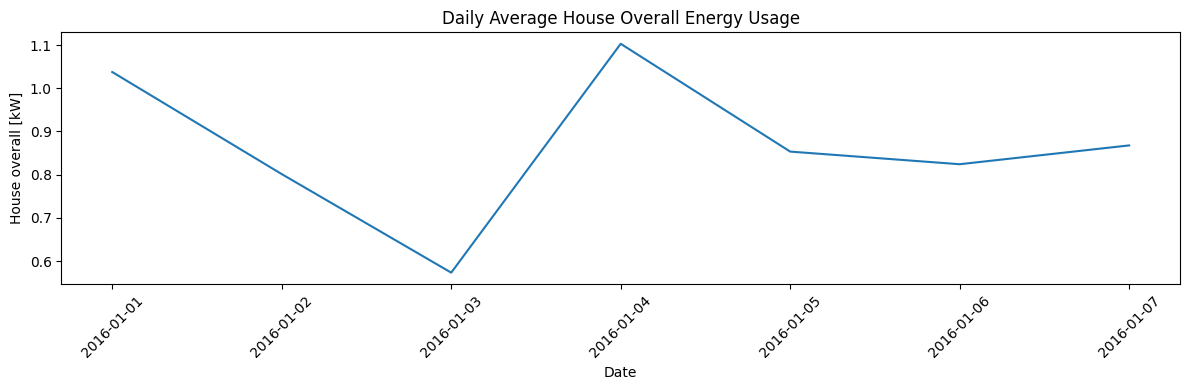

In [13]:
daily = df_long.resample('D', on='time').mean(numeric_only=True)

plt.figure(figsize=(12,4))
plt.plot(daily.index, daily['House overall [kW]'])
plt.title("Daily Average House Overall Energy Usage")
plt.xlabel("Date")
plt.ylabel("House overall [kW]")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

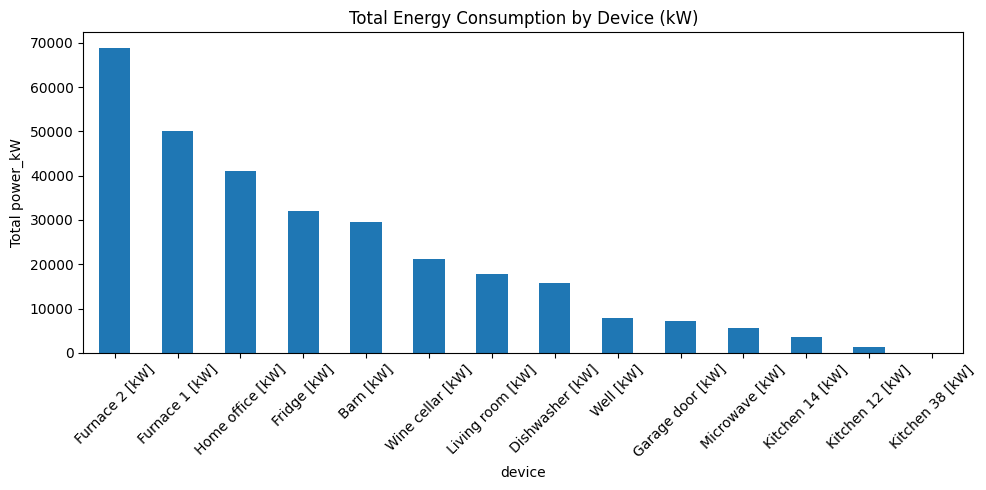

In [14]:
device_usage = df_long.groupby("device")["power_kW"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
device_usage.plot(kind='bar')
plt.title("Total Energy Consumption by Device (kW)")
plt.ylabel("Total power_kW")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

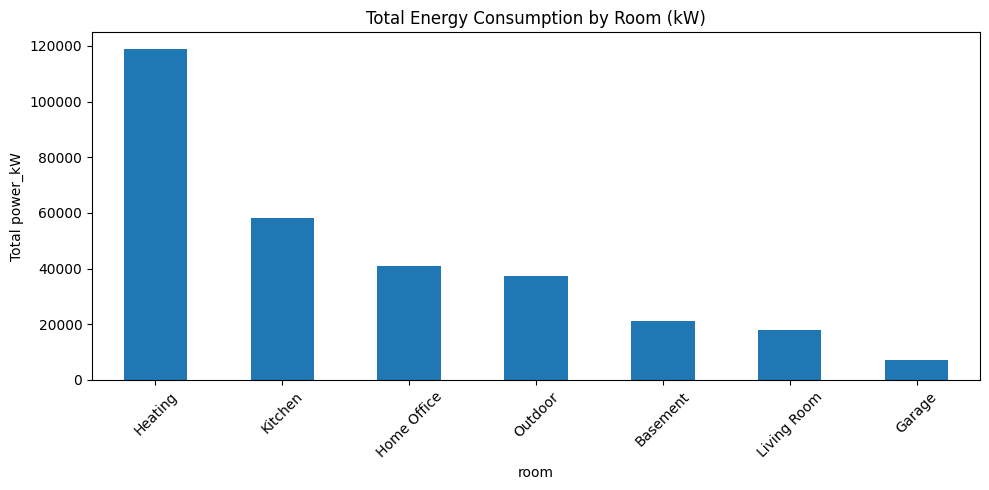

In [15]:
room_usage = df_long.groupby("room")["power_kW"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
room_usage.plot(kind='bar')
plt.title("Total Energy Consumption by Room (kW)")
plt.ylabel("Total power_kW")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

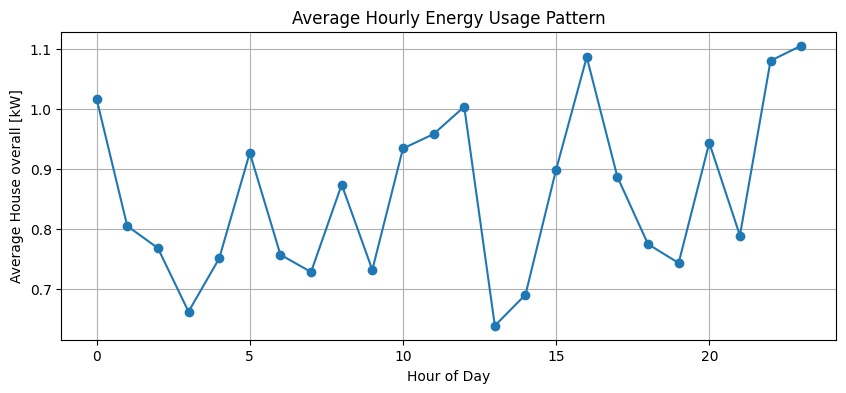

In [16]:
df_long['hour'] = df_long['time'].dt.hour
hourly_pattern = df_long.groupby('hour')['House overall [kW]'].mean()

plt.figure(figsize=(10,4))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o')
plt.title("Average Hourly Energy Usage Pattern")
plt.xlabel("Hour of Day")
plt.ylabel("Average House overall [kW]")
plt.grid(True)
plt.show()


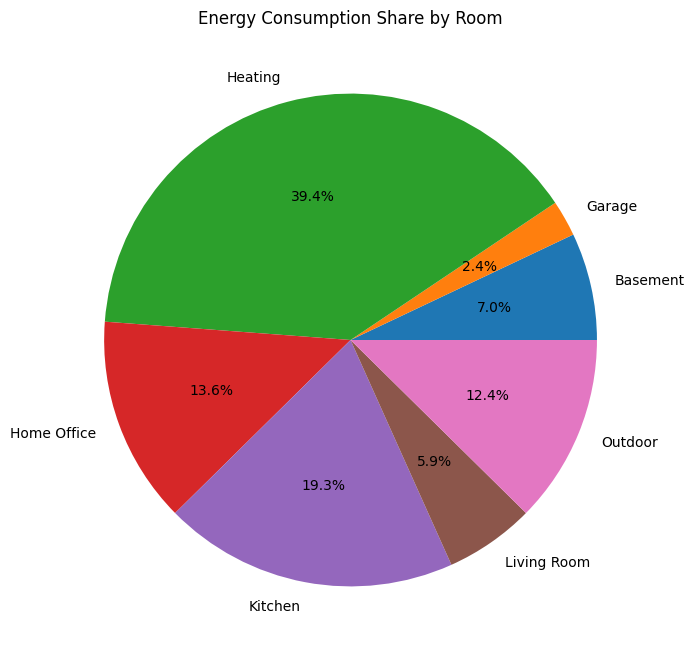

In [17]:
room_usage = df_long.groupby("room")["power_kW"].sum()
plt.figure(figsize=(8,8))
plt.pie(room_usage, labels=room_usage.index, autopct='%1.1f%%')
plt.title("Energy Consumption Share by Room")
plt.show()


In [ ]:
df_long.to_csv("organized_energy_data.csv", index=False)

## Module 2: Data Cleaning and Preprocessing  

### Resampling the data in form of hour

In [18]:
df_long=pd.read_csv('./organized_energy_data_1.csv')
df_long['time'] = pd.to_datetime(df_long['time'])

In [19]:
df_long['time_hour'] = df_long['time'].dt.floor('h')
df_hourly = (
    df_long
    .groupby(['time_hour', 'device', 'room'], as_index=False)
    .agg(
        power_kW=('power_kW', 'sum'),              
        house_overall=('House overall [kW]', 'sum')  
    )
    .rename(columns={'time_hour': 'time', 'house_overall': 'House overall [kW]'})
)

In [20]:
df_hourly

,time,device,room,power_kW,House overall [kW]
0,2016-01-01 05:00:00,Barn [kW],Outdoor,349.375683,4274.192867
1,2016-01-01 05:00:00,Dishwasher [kW],Kitchen,198.312077,4274.192867
2,2016-01-01 05:00:00,Fridge [kW],Kitchen,239.270767,4274.192867
3,2016-01-01 05:00:00,Furnace 1 [kW],Heating,752.584050,4274.192867
4,2016-01-01 05:00:00,Furnace 2 [kW],Heating,849.664267,4274.192867
...,...,...,...,...,...
3887,2016-01-12 18:00:00,Kitchen 38 [kW],Kitchen,0.026276,2446.917894
3888,2016-01-12 18:00:00,Living room [kW],Living Room,95.048914,2446.917894
3889,2016-01-12 18:00:00,Microwave [kW],Kitchen,27.810483,2446.917894
3890,2016-01-12 18:00:00,Well [kW],Outdoor,55.822206,2446.917894


### Handling missing values

In [21]:
df_hourly = df_hourly.fillna(method='ffill').fillna(method='bfill')

/tmp/ipykernel_1824/3359247515.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_hourly = df_hourly.fillna(method='ffill').fillna(method='bfill')


### Outlier detection

In [22]:
Q1_power=df_hourly['power_kW'].quantile(0.25)
Q3_power=df_hourly['power_kW'].quantile(0.75)
IQR_power=Q3_power-Q1_power

lower_power=Q1_power-1.5*IQR_power
upper_power=Q3_power+1.5*IQR_power

df_hourly['outlier_power']=(df_hourly['power_kW']<lower_power) | (df_hourly['power_kW']>upper_power)

Q1_house=df_hourly['House overall [kW]'].quantile(0.25)
Q3_house=df_hourly['House overall [kW]'].quantile(0.75)
IQR_house=Q3_house - Q1_house

lower_house=Q1_house-1.5*IQR_house
upper_house=Q3_house+1.5*IQR_house

df_hourly['outlier_house']=(df_hourly['House overall [kW]'] < lower_house) |(df_hourly['House overall [kW]'] > upper_house)

df_hourly['is_outlier'] = df_hourly['outlier_power'] | df_hourly['outlier_house']

outliers_df = df_hourly[df_hourly['is_outlier'] == True]
print(outliers_df.head())
print("Total combined outliers:", len(outliers_df))
print("Power column outliers:", df_hourly['outlier_power'].sum())
print("House overall column outliers:", df_hourly['outlier_house'].sum())


                 time           device     room    power_kW  \
0 2016-01-01 05:00:00        Barn [kW]  Outdoor  349.375683   
1 2016-01-01 05:00:00  Dishwasher [kW]  Kitchen  198.312077   
2 2016-01-01 05:00:00      Fridge [kW]  Kitchen  239.270767   
3 2016-01-01 05:00:00   Furnace 1 [kW]  Heating  752.584050   
4 2016-01-01 05:00:00   Furnace 2 [kW]  Heating  849.664267   

   House overall [kW]  outlier_power  outlier_house  is_outlier  
0         4274.192867          False           True        True  
1         4274.192867          False           True        True  
2         4274.192867          False           True        True  
3         4274.192867           True           True        True  
4         4274.192867           True           True        True  
Total combined outliers: 1030
Power column outliers: 107
House overall column outliers: 966


### Normalizing values

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_hourly_scaled = df_hourly.copy()
df_hourly_scaled[['power_kW','House overall [kW]']] = scaler.fit_transform(df_hourly[['power_kW','House overall [kW]']])
df_hourly_scaled

,time,device,room,power_kW,House overall [kW],outlier_power,outlier_house,is_outlier
0,2016-01-01 05:00:00,Barn [kW],Outdoor,0.244733,0.328239,False,True,True
1,2016-01-01 05:00:00,Dishwasher [kW],Kitchen,0.138910,0.328239,False,True,True
2,2016-01-01 05:00:00,Fridge [kW],Kitchen,0.167602,0.328239,False,True,True
3,2016-01-01 05:00:00,Furnace 1 [kW],Heating,0.527188,0.328239,True,True,True
4,2016-01-01 05:00:00,Furnace 2 [kW],Heating,0.595195,0.328239,True,True,True
...,...,...,...,...,...,...,...,...
3887,2016-01-12 18:00:00,Kitchen 38 [kW],Kitchen,0.000006,0.137729,False,False,False
3888,2016-01-12 18:00:00,Living room [kW],Living Room,0.066572,0.137729,False,False,False
3889,2016-01-12 18:00:00,Microwave [kW],Kitchen,0.019470,0.137729,False,False,False
3890,2016-01-12 18:00:00,Well [kW],Outdoor,0.039093,0.137729,False,False,False


## Module 3: Feature Engineering 

### Extract relevant time-based features

In [24]:
df_hourly_scaled['hour'] = df_hourly_scaled['time'].dt.hour
df_hourly_scaled['day'] = df_hourly_scaled['time'].dt.day
df_hourly_scaled['weekday'] = df_hourly_scaled['time'].dt.weekday
df_hourly_scaled['week'] = df_hourly_scaled['time'].dt.isocalendar().week.astype(int)
df_hourly_scaled['month'] = df_hourly_scaled['time'].dt.month

# Weekend flag (0 = weekday, 1 = weekend)
df_hourly_scaled['is_weekend'] = df_hourly_scaled['weekday'].apply(lambda x: 1 if x>=5 else 0)

def season_from_month(m):
    if m in [12,1,2]:
        return "Winter"
    elif m in [3,4,5]:
        return "Spring"
    elif m in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df_hourly_scaled['season'] = df_hourly_scaled['month'].apply(season_from_month)

print(df_hourly_scaled.head())


                 time           device     room  power_kW  House overall [kW]  \
0 2016-01-01 05:00:00        Barn [kW]  Outdoor  0.244733            0.328239   
1 2016-01-01 05:00:00  Dishwasher [kW]  Kitchen  0.138910            0.328239   
2 2016-01-01 05:00:00      Fridge [kW]  Kitchen  0.167602            0.328239   
3 2016-01-01 05:00:00   Furnace 1 [kW]  Heating  0.527188            0.328239   
4 2016-01-01 05:00:00   Furnace 2 [kW]  Heating  0.595195            0.328239   

   outlier_power  outlier_house  is_outlier  hour  day  weekday  week  month  \
0          False           True        True     5    1        4    53      1   
1          False           True        True     5    1        4    53      1   
2          False           True        True     5    1        4    53      1   
3           True           True        True     5    1        4    53      1   
4           True           True        True     5    1        4    53      1   

   is_weekend  season  
0       

### Create lag features and moving averages for time series learning

In [25]:
df_hourly_scaled = df_hourly_scaled.sort_values(['device', 'time'])

In [26]:
for lag in [1, 24, 48]:
    df_hourly_scaled[f'power_lag_{lag}'] = (
        df_hourly_scaled.groupby('device')['power_kW'].shift(lag)
    )

for lag in [1, 24, 48]:
    df_hourly_scaled[f'house_lag_{lag}'] = (
        df_hourly_scaled['House overall [kW]'].shift(lag)
    )


In [27]:
for window in [3, 24, 72]:
    df_hourly_scaled[f'power_roll_{window}'] = (
        df_hourly_scaled.groupby('device')['power_kW']
        .transform(lambda s: s.rolling(window=window, min_periods=1).mean())
    )
for window in [3, 24, 72]:
    df_hourly_scaled[f'house_roll_{window}'] = (
        df_hourly_scaled['House overall [kW]']
        .rolling(window=window, min_periods=1)
        .mean()
    )


In [28]:
df_features = df_hourly_scaled.dropna().reset_index(drop=True)
print(df_features.shape)
print(df_features.head())


(3220, 27)
                 time     device     room  power_kW  House overall [kW]  \
0 2016-01-03 05:00:00  Barn [kW]  Outdoor  0.254935            0.173207   
1 2016-01-03 06:00:00  Barn [kW]  Outdoor  0.090435            0.144309   
2 2016-01-03 07:00:00  Barn [kW]  Outdoor  0.259354            0.156814   
3 2016-01-03 08:00:00  Barn [kW]  Outdoor  0.412297            0.218636   
4 2016-01-03 09:00:00  Barn [kW]  Outdoor  0.094185            0.040423   

   outlier_power  outlier_house  is_outlier  hour  day  ...  power_lag_48  \
0          False          False       False     5    3  ...      0.244733   
1          False          False       False     6    3  ...      0.133260   
2          False          False       False     7    3  ...      0.165658   
3           True          False        True     8    3  ...      0.251006   
4          False           True        True     9    3  ...      0.087393   

   house_lag_1  house_lag_24  house_lag_48 power_roll_3  power_roll_24  \
0

In [29]:
df_features = df_features.sort_values("time").reset_index(drop=True)

In [ ]:
df_features.to_csv('features_1.csv',index=False)

### Prepare final feature set for ML model input

In [30]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df_features, test_size=0.15, shuffle=False)
train, val = train_test_split(train, test_size=0.176, shuffle=False)
print(len(train), len(val), len(test))

2255 482 483


## Module 4: Baseline Model Development 

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
df_features=pd.read_csv('features_1.csv')

In [33]:
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
df_features['target'] = df_features['House overall [kW]'].shift(-1)
df_features = df_features.dropna().reset_index(drop=True)
scaler=LabelEncoder()
df_features['season']=scaler.fit_transform(df_features['season'])
# Columns to drop
drop_cols = [
    'time',
    'target',
    'device',
    'room',
    'House overall [kW]'
]

X = df_features.drop(columns=drop_cols)
y = df_features['target']

# Train-val-test split again for the target column
train, test = train_test_split(df_features, test_size=0.15, shuffle=False)
train, val = train_test_split(train, test_size=0.176, shuffle=False)

X_train = train.drop(columns=drop_cols)
y_train = train['target']
X_val   = val.drop(columns=drop_cols)
y_val   = val['target']
X_test  = test.drop(columns=drop_cols)
y_test  = test['target']

# Train baseline Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# Evaluation metrics
mae_val = mean_absolute_error(y_val, val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, val_pred))
mae_test=mean_absolute_error(y_test, test_pred)
rmse_test= np.sqrt(mean_squared_error(y_test, test_pred))
print("validation mae:", mae_val)
print("validation rmse:", rmse_val)
print('test mse:',mae_test)
print('test rmse:',rmse_test)

validation mae: 0.013590712685526071
validation rmse: 0.01618068772903036
test mse: 0.011497891845792495
test rmse: 0.014857686400081855


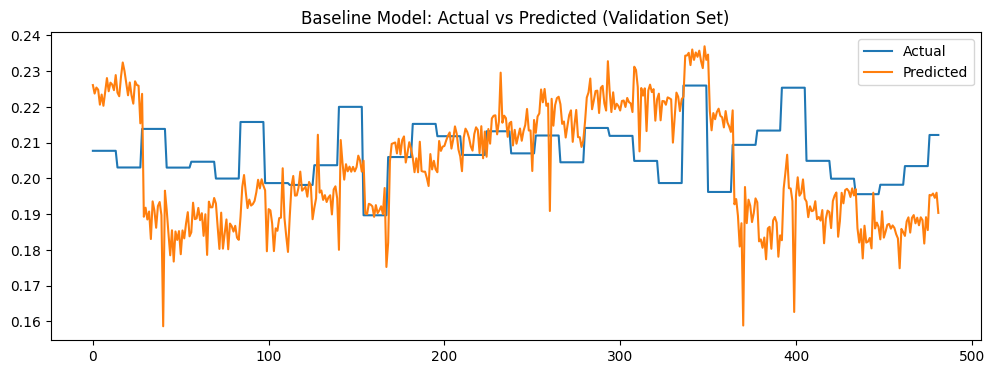

In [34]:
plt.figure(figsize=(12,4))
plt.plot(y_val.values, label="Actual")
plt.plot(val_pred, label="Predicted")
plt.title("Baseline Model: Actual vs Predicted (Validation Set)")
plt.legend()
plt.show()


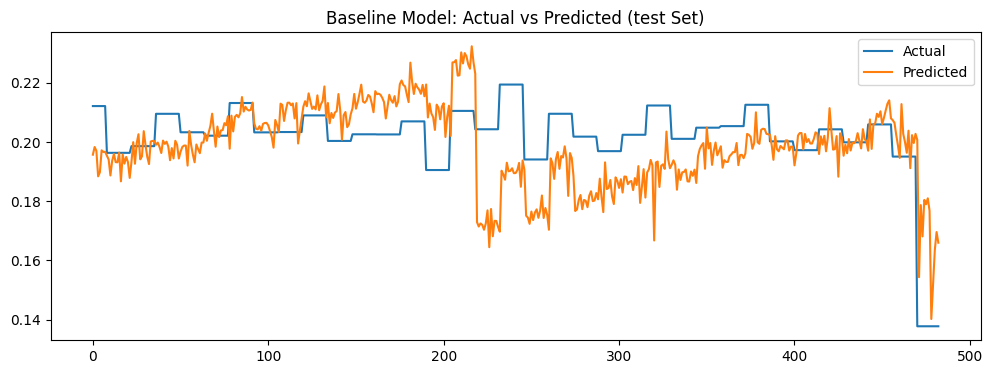

In [35]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values, label="Actual")
plt.plot(test_pred, label="Predicted")
plt.title("Baseline Model: Actual vs Predicted (test Set)")
plt.legend()
plt.show()



In [36]:
import joblib

joblib.dump(model, "baseline_ridge_model_1.pkl")
print("Model saved successfully.")


Model saved successfully.


In [37]:
joblib.dump(scaler, "scaler_1.pkl")

['scaler_1.pkl']

## Module 5: LSTM Model Development 